# HAM10000 — Generación con Derm-T2IM

Genera variaciones de imágenes reales de melanoma usando **Derm-T2IM**, un modelo Stable Diffusion
fine-tuneado específicamente sobre HAM10000 + ISIC Archive (arXiv 2401.05159).

Se generan **dos sets** desde las 801 imágenes reales de melanoma del split de train:

| Set | strength | Imágenes | Hipótesis |
|-----|---------|---------|----------|
| `derm_s040` | 0.40 | 1602 (×2 por original) | Variaciones clínicas diversas |
| `derm_s005` | 0.05 | 1602 (×2 por original) | Perturbaciones sutiles casi-originales |

**Prerequisitos Drive:** `classification_data.zip` (para obtener la lista de mel train)

In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'CUDA: {name}  ({vram:.1f} GB)')
    DEVICE = torch.device('cuda')
else:
    print('ADVERTENCIA: sin GPU — la generación será muy lenta')
    DEVICE = torch.device('cpu')

print(f'IN_COLAB={IN_COLAB}  device={DEVICE}')

CUDA: NVIDIA L4  (23.7 GB)
IN_COLAB=True  device=cuda


In [2]:
from pathlib import Path
import zipfile, json, subprocess, sys

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_ROOT  = Path('/content/drive/MyDrive/ham10000-augmentation')
    ZIP_PATH    = DRIVE_ROOT / 'classification_data.zip'
    IMAGES_DIR  = Path('/content/images')
    SPLITS_DIR  = Path('/content/splits')
    # Outputs van a Drive (persistentes entre sesiones)
    OUT_S040    = DRIVE_ROOT / 'synthetic' / 'derm_s040'
    OUT_S005    = DRIVE_ROOT / 'synthetic' / 'derm_s005'
    MODEL_PATH  = Path('/content/Derm-T2IM.safetensors')
else:
    PROJECT_ROOT = Path.cwd()
    ZIP_PATH     = PROJECT_ROOT / 'data/processed/classification_data.zip'
    IMAGES_DIR   = PROJECT_ROOT / 'data/processed/images'
    SPLITS_DIR   = PROJECT_ROOT / 'data/processed/splits'
    OUT_S040     = PROJECT_ROOT / 'data/synthetic/derm_s040'
    OUT_S005     = PROJECT_ROOT / 'data/synthetic/derm_s005'
    MODEL_PATH   = PROJECT_ROOT / 'models/Derm-T2IM.safetensors'

OUT_S040.mkdir(parents=True, exist_ok=True)
OUT_S005.mkdir(parents=True, exist_ok=True)

print(f'OUT_S040: {OUT_S040}')
print(f'OUT_S005: {OUT_S005}')
print(f'MODEL:    {MODEL_PATH}')

Mounted at /content/drive
OUT_S040: /content/drive/MyDrive/ham10000-augmentation/synthetic/derm_s040
OUT_S005: /content/drive/MyDrive/ham10000-augmentation/synthetic/derm_s005
MODEL:    /content/Derm-T2IM.safetensors


In [3]:
# ── Dependencias ──────────────────────────────────────────────────────────────
def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import diffusers; print(f'diffusers {diffusers.__version__}')
except ImportError:
    pip('diffusers[torch]', 'transformers', 'accelerate', 'omegaconf')
    import diffusers

try:
    import xformers; print(f'xformers {xformers.__version__}')
    USE_XFORMERS = True
except ImportError:
    USE_XFORMERS = False
    print('xformers no disponible — continuando sin él')

print('Dependencias listas')

diffusers 0.37.1
xformers no disponible — continuando sin él
Dependencias listas


In [4]:
# ── Estado rápido ─────────────────────────────────────────────────────────────
n_s040 = len(list(OUT_S040.glob('*.jpg')))
n_s005 = len(list(OUT_S005.glob('*.jpg')))
model_ok = MODEL_PATH.exists()

print(f'Modelo descargado: {"✅" if model_ok else "⬜"} {MODEL_PATH.name}')
print(f'derm_s040:  {n_s040} imágenes  {"✅ completo" if n_s040 >= 1602 else f"(faltan {1602-n_s040})"}')
print(f'derm_s005:  {n_s005} imágenes  {"✅ completo" if n_s005 >= 1602 else f"(faltan {1602-n_s005})"}')

Modelo descargado: ⬜ Derm-T2IM.safetensors
derm_s040:  0 imágenes  (faltan 1602)
derm_s005:  0 imágenes  (faltan 1602)


In [5]:
# ── Extraer imágenes reales + splits (si no están ya) ─────────────────────────
if IN_COLAB:
    IMAGES_DIR.mkdir(parents=True, exist_ok=True)
    SPLITS_DIR.mkdir(parents=True, exist_ok=True)
    if len(list(IMAGES_DIR.glob('*.jpg'))) < 100:
        print('Extrayendo classification_data.zip...')
        with zipfile.ZipFile(ZIP_PATH) as zf:
            for m in zf.infolist():
                data = zf.read(m.filename)
                if m.filename.startswith('images/') and m.filename.endswith('.jpg'):
                    (IMAGES_DIR / Path(m.filename).name).write_bytes(data)
                elif m.filename.startswith('splits/') and m.filename.endswith('.csv'):
                    (SPLITS_DIR / Path(m.filename).name).write_bytes(data)
        print(f'  {len(list(IMAGES_DIR.glob("*.jpg")))} imágenes extraídas')
    else:
        print(f'Imágenes ya en /content/images/ ({len(list(IMAGES_DIR.glob("*.jpg")))})')

Extrayendo classification_data.zip...
  7818 imágenes extraídas


In [6]:
# ── Lista de imágenes melanoma del split de train ─────────────────────────────
import pandas as pd

df_train = pd.read_csv(SPLITS_DIR / 'train.csv')
mel_rows = df_train[df_train['label'] == 1]

def resolve(rel):
    if IN_COLAB: return IMAGES_DIR / Path(rel).name
    return Path.cwd() / rel

mel_paths = [resolve(r) for r in mel_rows['image_path']]
mel_paths = [p for p in mel_paths if p.exists()]
print(f'Imágenes mel train disponibles: {len(mel_paths)}')

# Cada imagen se usará 2 veces → 1602 generaciones por set
SOURCE_PATHS = mel_paths * 2   # [img0, img1, ..., img800, img0, img1, ...]
N_TOTAL = len(SOURCE_PATHS)
print(f'Total a generar por set: {N_TOTAL}')

Imágenes mel train disponibles: 801
Total a generar por set: 1602


In [7]:
# ── Descargar modelo Derm-T2IM ────────────────────────────────────────────────
MODEL_URL = 'https://huggingface.co/MAli-Farooq/Derm-T2IM/resolve/main/Derm-T2IM.safetensors'

if not MODEL_PATH.exists():
    print(f'Descargando Derm-T2IM (~2-4 GB)...')
    subprocess.check_call(['wget', '-q', '--show-progress', MODEL_URL, '-O', str(MODEL_PATH)])
    size_gb = MODEL_PATH.stat().st_size / 1e9
    print(f'Descargado: {size_gb:.2f} GB')
else:
    size_gb = MODEL_PATH.stat().st_size / 1e9
    print(f'Modelo ya descargado ({size_gb:.2f} GB)')

Descargando Derm-T2IM (~2-4 GB)...
Descargado: 4.27 GB


In [8]:
# ── Cargar pipeline ───────────────────────────────────────────────────────────
from diffusers import StableDiffusionPipeline, AutoPipelineForImage2Image
from PIL import Image

print('Cargando Derm-T2IM...')
base_pipe = StableDiffusionPipeline.from_single_file(
    str(MODEL_PATH),
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False,
)

pipe = AutoPipelineForImage2Image.from_pipe(base_pipe)
pipe = pipe.to(DEVICE)

if USE_XFORMERS:
    pipe.enable_xformers_memory_efficient_attention()
    print('xformers activado')

pipe.set_progress_bar_config(disable=True)
print('Pipeline listo')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Cargando Derm-T2IM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Pipeline listo


In [9]:
# ── Configuración de generación ───────────────────────────────────────────────
PROMPT    = 'dermoscopy image of melanoma skin lesion, ABCD criteria, clinical photography, high quality'
NEG_PROMPT = 'blurry, low quality, artifact, non-skin, cartoon'
STEPS     = 30
CFG       = 7.0
SEED      = 42

SETS = [
    {'name': 'derm_s040', 'strength': 0.40, 'out_dir': OUT_S040},
    {'name': 'derm_s005', 'strength': 0.05, 'out_dir': OUT_S005},
]

print(f'Prompt:    {PROMPT}')
print(f'Steps:     {STEPS}  |  CFG: {CFG}  |  Seed: {SEED}')
for s in SETS:
    n_done = len(list(s['out_dir'].glob('*.jpg')))
    print(f"  {s['name']}  strength={s['strength']}  → {n_done}/{N_TOTAL} ya generadas")

Prompt:    dermoscopy image of melanoma skin lesion, ABCD criteria, clinical photography, high quality
Steps:     30  |  CFG: 7.0  |  Seed: 42
  derm_s040  strength=0.4  → 0/1602 ya generadas
  derm_s005  strength=0.05  → 0/1602 ya generadas


In [10]:
# ── Generación — resumible por set ────────────────────────────────────────────
import time
from tqdm.auto import tqdm

generator = torch.Generator(device=DEVICE).manual_seed(SEED)

for cfg_set in SETS:
    name     = cfg_set['name']
    strength = cfg_set['strength']
    out_dir  = cfg_set['out_dir']

    existing = set(p.stem for p in out_dir.glob('*.jpg'))
    pending  = [(i, p) for i, p in enumerate(SOURCE_PATHS)
                if f'{name}_{i:04d}' not in existing]

    if not pending:
        print(f'✅ {name} ya completo ({N_TOTAL} imágenes)')
        continue

    print(f'\n── {name}  strength={strength}  ({len(pending)} pendientes) ──')
    t0 = time.time()

    for i, src_path in tqdm(pending, desc=name):
        fname = out_dir / f'{name}_{i:04d}.jpg'
        try:
            src_img = Image.open(src_path).convert('RGB').resize((512, 512))
            out_img = pipe(
                prompt          = PROMPT,
                negative_prompt = NEG_PROMPT,
                image           = src_img,
                strength        = strength,
                num_inference_steps = STEPS,
                guidance_scale  = CFG,
                generator       = generator,
            ).images[0]
            out_img.save(fname, quality=95)
        except Exception as e:
            print(f'  Error en {src_path.name}: {e}')
            continue

        # Progreso cada 100 imágenes
        n_done = len(list(out_dir.glob('*.jpg')))
        if n_done % 100 == 0:
            elapsed = time.time() - t0
            rate    = n_done / elapsed
            eta_min = (N_TOTAL - n_done) / rate / 60 if rate > 0 else 0
            print(f'  {n_done}/{N_TOTAL}  |  {rate:.1f} img/s  |  ETA {eta_min:.0f} min')

    n_final = len(list(out_dir.glob('*.jpg')))
    print(f'✅ {name} completo: {n_final} imágenes')

print('\nGeneración terminada.')


── derm_s040  strength=0.4  (1602 pendientes) ──


derm_s040:   0%|          | 0/1602 [00:00<?, ?it/s]

  100/1602  |  1.0 img/s  |  ETA 25 min
  200/1602  |  1.0 img/s  |  ETA 23 min
  300/1602  |  1.0 img/s  |  ETA 22 min
  400/1602  |  1.0 img/s  |  ETA 20 min
  500/1602  |  1.0 img/s  |  ETA 19 min
  600/1602  |  1.0 img/s  |  ETA 17 min
  700/1602  |  1.0 img/s  |  ETA 15 min
  800/1602  |  1.0 img/s  |  ETA 14 min
  900/1602  |  1.0 img/s  |  ETA 12 min
  1000/1602  |  1.0 img/s  |  ETA 10 min
  1100/1602  |  1.0 img/s  |  ETA 9 min
  1200/1602  |  1.0 img/s  |  ETA 7 min
  1300/1602  |  1.0 img/s  |  ETA 5 min
  1400/1602  |  1.0 img/s  |  ETA 3 min
  1500/1602  |  1.0 img/s  |  ETA 2 min
  1600/1602  |  1.0 img/s  |  ETA 0 min
✅ derm_s040 completo: 1602 imágenes

── derm_s005  strength=0.05  (1602 pendientes) ──


derm_s005:   0%|          | 0/1602 [00:00<?, ?it/s]

  100/1602  |  3.0 img/s  |  ETA 8 min
  200/1602  |  3.0 img/s  |  ETA 8 min
  300/1602  |  3.0 img/s  |  ETA 7 min
  400/1602  |  3.0 img/s  |  ETA 7 min
  500/1602  |  3.0 img/s  |  ETA 6 min
  600/1602  |  3.0 img/s  |  ETA 6 min
  700/1602  |  3.0 img/s  |  ETA 5 min
  800/1602  |  3.0 img/s  |  ETA 4 min
  900/1602  |  3.0 img/s  |  ETA 4 min
  1000/1602  |  3.0 img/s  |  ETA 3 min
  1100/1602  |  3.0 img/s  |  ETA 3 min
  1200/1602  |  3.0 img/s  |  ETA 2 min
  1300/1602  |  3.0 img/s  |  ETA 2 min
  1400/1602  |  2.9 img/s  |  ETA 1 min
  1500/1602  |  2.9 img/s  |  ETA 1 min
  1600/1602  |  2.9 img/s  |  ETA 0 min
✅ derm_s005 completo: 1602 imágenes

Generación terminada.


derm_s040: 1602 imágenes


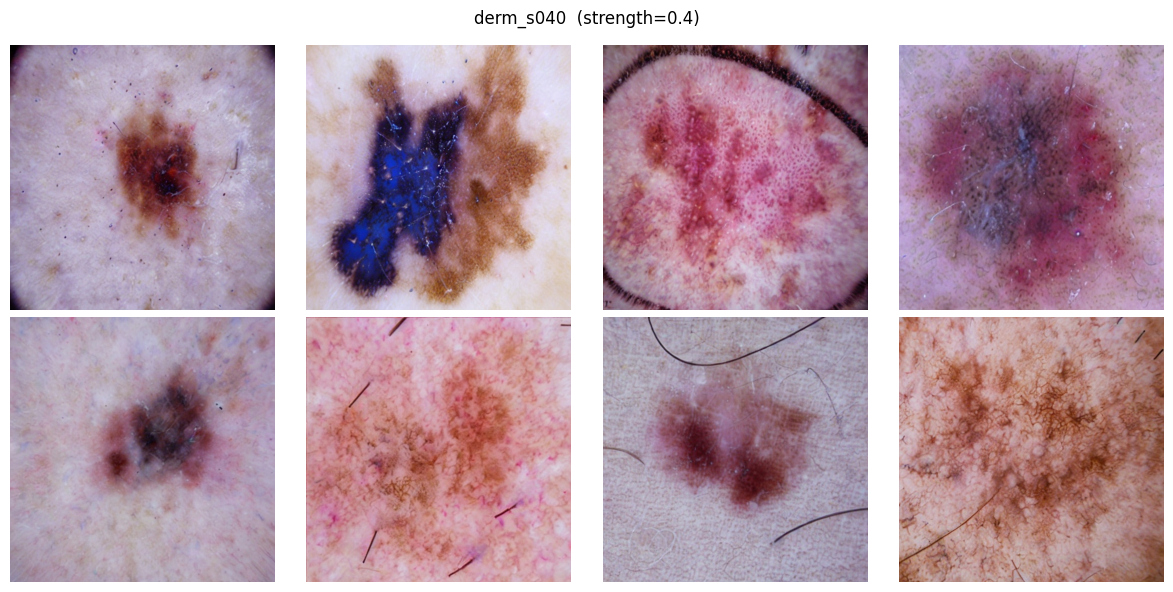

derm_s005: 1602 imágenes


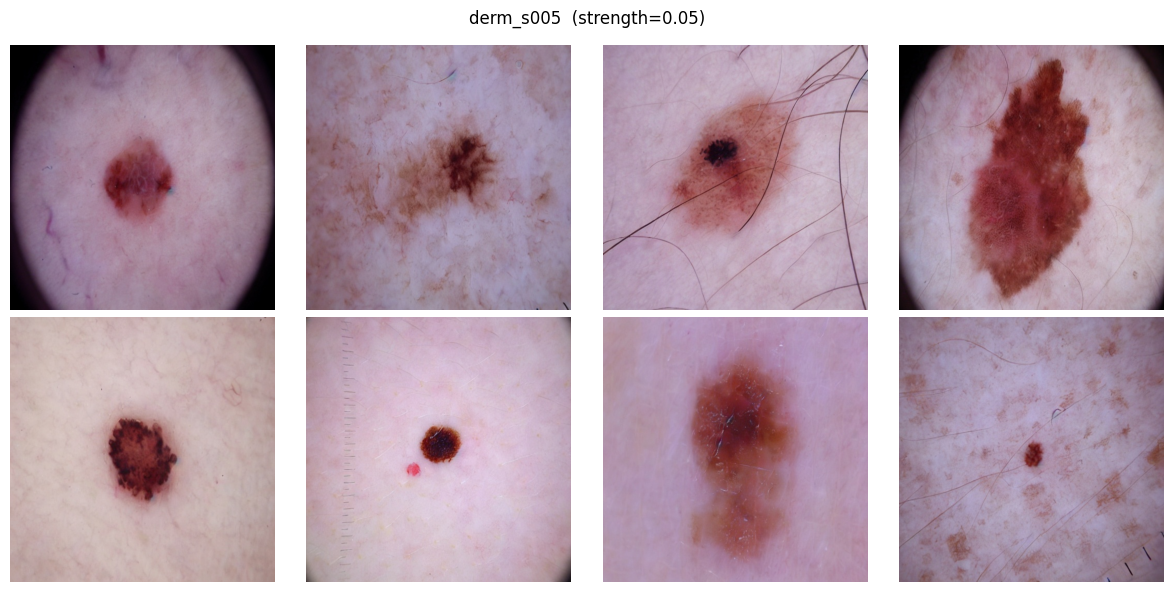


Paras usar en clasificación:
  derm_s040 → derm_s040_2x, derm_s040_2x_ft
  derm_s005 → derm_s005_2x, derm_s005_2x_ft


In [11]:
# ── Resumen y grids de muestra ────────────────────────────────────────────────
import matplotlib.pyplot as plt, random

for cfg_set in SETS:
    name    = cfg_set['name']
    out_dir = cfg_set['out_dir']
    imgs    = sorted(out_dir.glob('*.jpg'))
    print(f'{name}: {len(imgs)} imágenes')

    if len(imgs) < 8:
        continue

    sample = random.sample(imgs, 8)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(f'{name}  (strength={cfg_set["strength"]})', fontsize=12)
    for ax, p in zip(axes.flat, sample):
        ax.imshow(Image.open(p))
        ax.axis('off')
    fig.tight_layout()
    plt.show()

print('\nParas usar en clasificación:')
print('  derm_s040 → derm_s040_2x, derm_s040_2x_ft')
print('  derm_s005 → derm_s005_2x, derm_s005_2x_ft')